# First SCF iteration

In [1]:
import numpy as np
from numpy.typing import NDArray

import matplotlib.pyplot as plt 

from py_mods.src.SCF.plot_utilities import plot_map
from py_mods.src.SCF.linalg import transformation_matrix
from py_mods.src.external.DIRAC_ME import (
    build_4c_one_Fock_from_h5,
    build_S_V_W_T_from_h5,
    get_nuc_charge,
    full_eri_from_checkpoint,
)
from py_mods.src.SCF.scf_kernels import calc_p_matrix_comp, calc_g_matrix

In [2]:
# load results
He_F0_eigvals = np.loadtxt("files/He_F_eigvals_1st_iter.dat")
He_F1_eigvals = np.loadtxt("files/He_F_eigvals_2nd_iter.dat")
He_F2_eigvals = np.loadtxt("files/He_F_eigvals_3rd_iter.dat")

# Zeroth iteration
We establised in a previous notebook that the zeroth iteration from the bare nucleus approximation is:

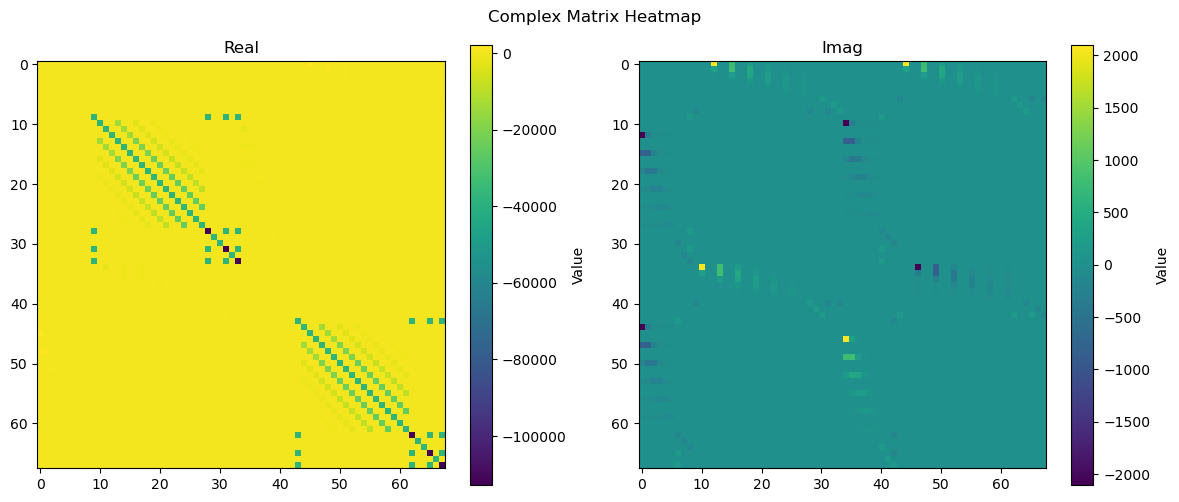

In [3]:
# Load
h5_filename = "files/He_checkpoint.h5"
F_0 = build_4c_one_Fock_from_h5(h5_filename)
S, V, W, T = build_S_V_W_T_from_h5(h5_filename)
nuc_charge = get_nuc_charge(h5_filename)
eri = full_eri_from_checkpoint(h5_filename)

H_core = T + V + W

plot_map(H_core)

In [4]:

# Orthogonalization
X = transformation_matrix(S)

# Diagonalization
F_p = X.T @ F_0 @ X
np.allclose(F_p, F_p.conj().T)

e, w = np.linalg.eigh(F_p)

e_red = [ei for i, ei in enumerate(e) if i % 2 == 0]

Eigenvalues are the same for the zeroth iteration: True
Mean absolute error for the zeroth iteration: 5.660383599745574e-11
Max absolute error for the zeroth iteration: 2.546585164964199e-10


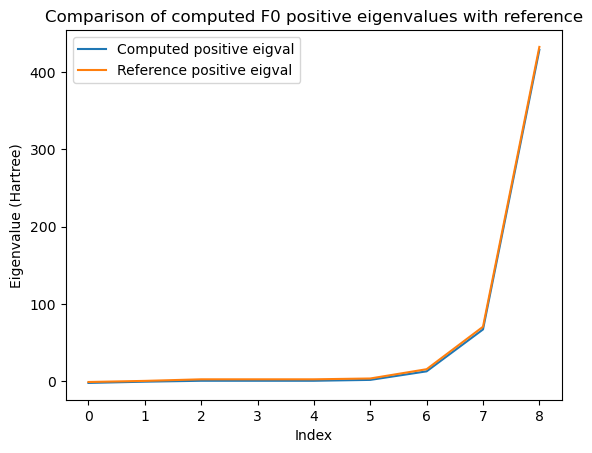

In [5]:
def plot_pos_eigval(e, reference=None, n=0):
    pos_eigval = [i for i in e.real if i > -0.5 * (137.035999177**2) * 2]
    # print(pos_eigval)

    n_LC = len(pos_eigval) // 2
    n_SC = len(e) // 2 - n_LC

    e_pairs = [ei for i, ei in enumerate(pos_eigval) if i % 2 == 0]
    x = [i for i in range(len(e_pairs))]

    plt.plot(x, e_pairs, label="Computed positive eigval")
    if reference is not None:
        plt.plot(x, He_F1_eigvals[-len(x) :], label="Reference positive eigval")
    plt.title(f"Comparison of computed F{n} positive eigenvalues with reference")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue (Hartree)")
    plt.legend()
    plt.show()

print(f"Eigenvalues are the same for the zeroth iteration: {np.allclose(e_red, He_F0_eigvals)}")
print(f"Mean absolute error for the zeroth iteration: {np.mean(np.abs(e_red - He_F0_eigvals))}")
print(f"Max absolute error for the zeroth iteration: {np.max(np.abs(e_red - He_F0_eigvals))}")

plot_pos_eigval(e, reference=He_F0_eigvals)

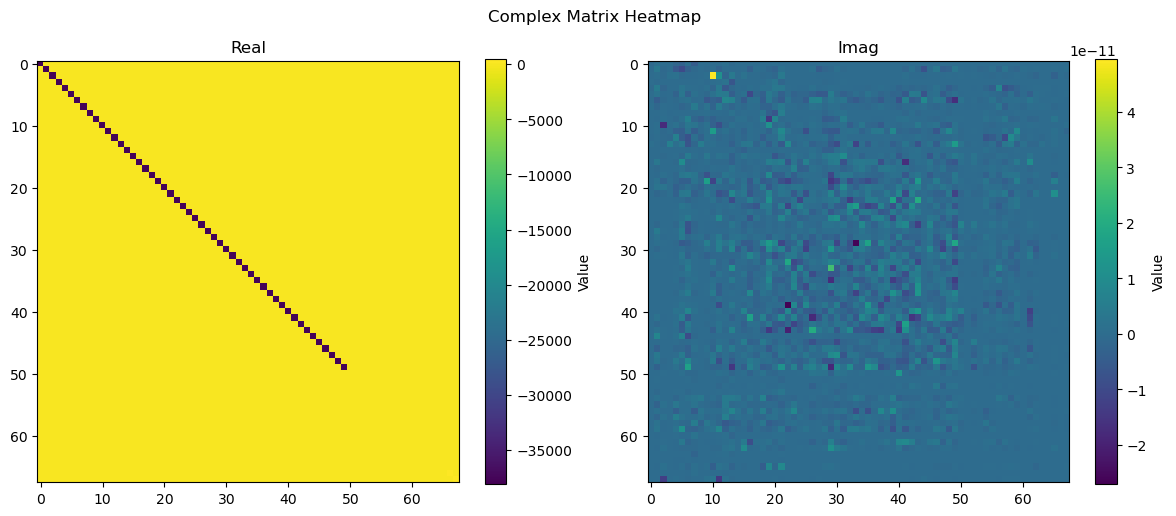

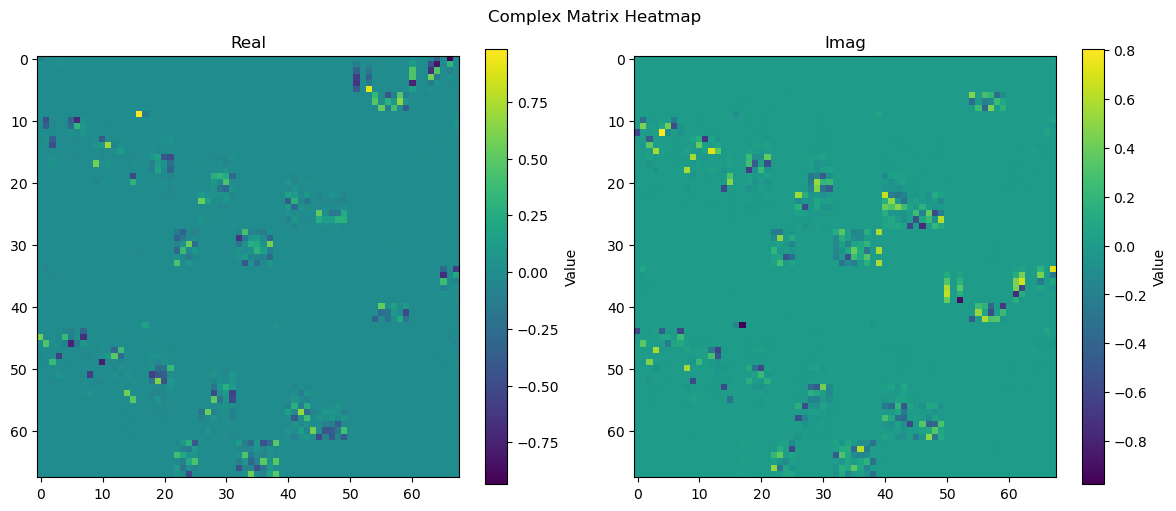

In [6]:
F_diag = np.linalg.inv(w) @ F_p @ w
plot_map(F_diag)
plot_map(w)

Now if we wish to transform back it is not as strightforward, as the eigenvectors are now ordered by pairs due to the definition of the 4c equation: 

$$

\begin{bmatrix}
h^{\alpha \alpha} & h^{\alpha \beta} \\
h^{\beta \alpha} & h^{\beta \beta}
\end{bmatrix} 
\begin{bmatrix}
c_{\alpha} \\
c_{\beta} 
\end{bmatrix}

= \varepsilon \begin{bmatrix}
S^{\alpha \alpha} & S^{\alpha \beta} \\
S^{\beta \alpha} & S^{\beta \beta}
\end{bmatrix}
\begin{bmatrix}
c_{\alpha} \\
c_{\beta}
\end{bmatrix}
$$

However, since the eigenvalues are reordered when using `eigh` (or manually in our case), it is necessary to somehow recover the $\alpha/\beta$ eigenvectors and place them in the correct order. For now we are going to assume that the $\alpha$ eigenvectors are the even ones (including zero) and the beta ones are the odd ones. That way, the rearangement of eigenvectors would be: 



In [7]:
def rearange_eigval_eigvec(eigval, eigvec):
    """Rearrange the eigenvalues and eigenvectors so alpha and beta spinors are separated."""
    n_tot = len(eigval)
    n_alpha = n_tot // 2 - 1

    rearr_eigvec = np.zeros_like(eigvec)
    rearr_eigval = np.zeros_like(eigval)

    for i in range(n_tot):
        if i % 2 == 0:
            rearr_eigvec[:, i // 2] = eigvec[:, i]
            rearr_eigval[i // 2] = eigval[i]

        if i % 2 != 0:
            rearr_eigvec[:, n_alpha + i // 2 + 1] = eigvec[:, i]
            rearr_eigval[n_alpha + i // 2 + 1] = eigval[i]

    return rearr_eigval, rearr_eigvec

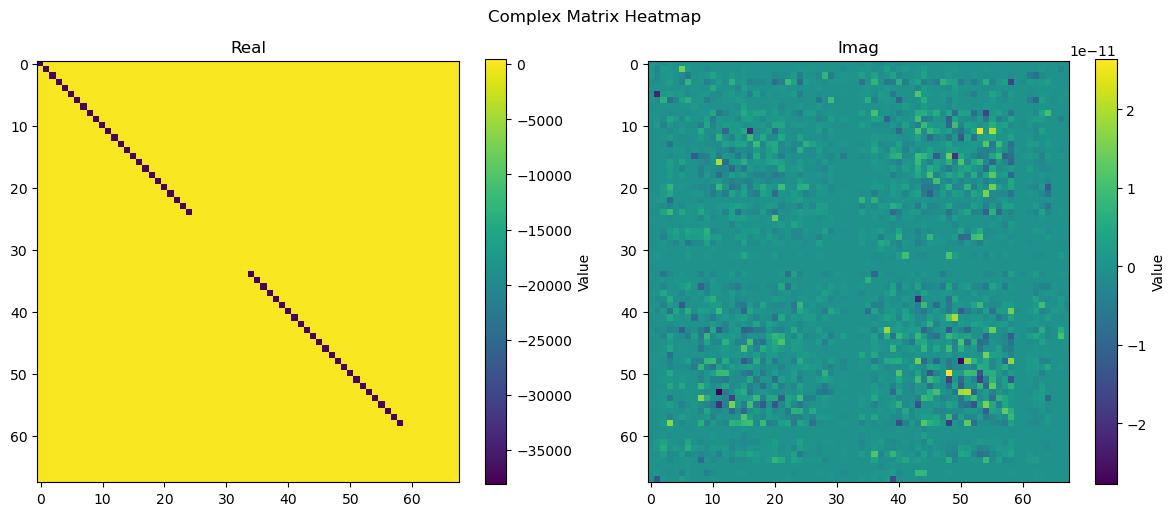

[-3.80656531e+04 -3.76531133e+04 -3.75908825e+04 -3.75908825e+04
 -3.75834603e+04 -3.75695597e+04 -3.75695597e+04 -3.75660575e+04
 -3.75657103e+04 -3.75630243e+04 -3.75630243e+04 -3.75628306e+04
 -3.75628306e+04 -3.75606839e+04 -3.75603785e+04 -3.75603785e+04
 -3.75596501e+04 -3.75596501e+04 -3.75596501e+04 -3.75595301e+04
 -3.75591299e+04 -3.75591299e+04 -3.75587670e+04 -3.75584758e+04
 -3.75584758e+04 -1.99966093e+00 -3.95813921e-01  7.80295811e-01
  7.80539634e-01  7.80539634e-01  1.91830569e+00  1.29727286e+01
  6.71264657e+01  4.28412332e+02 -3.80656531e+04 -3.76531133e+04
 -3.75908825e+04 -3.75908825e+04 -3.75834603e+04 -3.75695597e+04
 -3.75695597e+04 -3.75660575e+04 -3.75657103e+04 -3.75630243e+04
 -3.75630243e+04 -3.75628306e+04 -3.75628306e+04 -3.75606839e+04
 -3.75603785e+04 -3.75603785e+04 -3.75596501e+04 -3.75596501e+04
 -3.75596501e+04 -3.75595301e+04 -3.75591299e+04 -3.75591299e+04
 -3.75587670e+04 -3.75584758e+04 -3.75584758e+04 -1.99966093e+00
 -3.95813921e-01  7.80295

In [8]:
w.shape
e, w = rearange_eigval_eigvec(e, w)

plot_map(np.linalg.inv(w) @ F_p @ w)
print(e)

Where we have separated alpha and beta eigenvectors and have clear blocks. Now it is time to transform back to the original basis by multiplying the eigenvectors with the transformation matrix $X$ as in the regular scf:

$$
\begin{bmatrix}
c_{\alpha} \\
c_{\beta}
\end{bmatrix} =
\begin{bmatrix}
X & 0 \\
0 & X
\end{bmatrix}
\begin{bmatrix}
c_{\alpha}^{\text{orth}} \\
c_{\beta}^{\text{orth}}
\end{bmatrix}
$$

In [9]:
c_alpha_beta = X.T @ w

And with this we can try to define occupations. All negative eigenstates will be assumed to be occupied:

In [10]:
def alpha_beta_occupation(n_LC, n_bas, nuc_charge, charge=0, dist="Homogeneous"):

    n_SC = int(n_bas - n_LC)

    alpha_occ = np.zeros([n_bas])
    beta_occ = np.zeros([n_bas])

    alpha_occ[0:n_SC] = 0
    beta_occ[0:n_SC] = 0

    total_occ = int(nuc_charge - charge)

    if dist == "Homogeneous":
        if total_occ % 2 == 0:
            alpha_occ[n_SC : n_SC + total_occ // 2] = 1
            beta_occ[n_SC : n_SC + total_occ // 2] = 1
        else:
            alpha_occ[n_SC : n_SC + total_occ // 2 + 1] = 1
            beta_occ[n_SC : n_SC + total_occ // 2] = 1

    return alpha_occ, beta_occ

In [11]:
alpha_occ, beta_occ = alpha_beta_occupation(9, 34, nuc_charge, 0)

total_occ_det = np.concatenate([alpha_occ, beta_occ])
total_occ_det

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

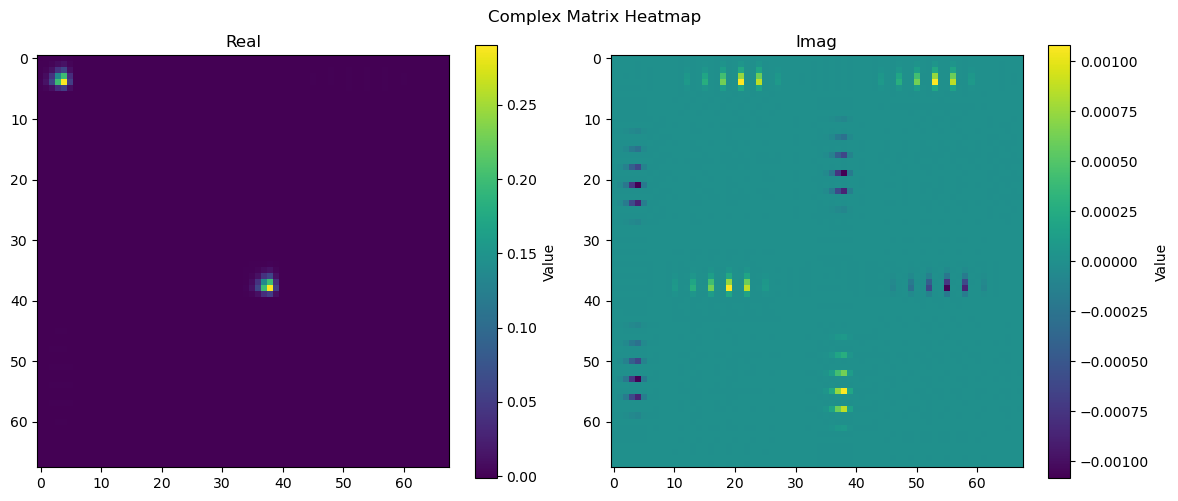

In [12]:
P_0 = calc_p_matrix_comp(c_alpha_beta.conj().T, c_alpha_beta, total_occ_det)
plot_map(P_0)

In [13]:
def g_matrix_4c(P):
    n_bas = P.shape[0]
    n_bas_half = n_bas // 2

    P_aa = P[0:n_bas_half, 0:n_bas_half]
    P_bb = P[n_bas_half:n_bas, n_bas_half:n_bas]
    P_ab = P[0:n_bas_half, n_bas_half:n_bas]
    P_ba = P[n_bas_half:n_bas, 0:n_bas_half]

    P_total = P_aa + P_bb
    # J from total density like in UHF
    J = np.einsum("mnsl, ls -> mn", eri, P_total)

    K_aa = np.einsum("psrq, sr -> pq", eri, P_aa)
    K_bb = np.einsum("psrq, sr -> pq", eri, P_bb)
    K_ab = np.einsum("psrq, sr -> pq", eri, P_ab)
    K_ba = np.einsum("psrq, sr -> pq", eri, P_ba)

    G_aa = J - K_aa
    G_bb = J - K_bb
    # No J as no different spin coulomb

    G_ab = -K_ab
    G_ba = -K_ba

    G_full = np.zeros((n_bas, n_bas), dtype=complex)
    G_full[0:n_bas_half, 0:n_bas_half] = G_aa
    G_full[n_bas_half:n_bas, n_bas_half:n_bas] = G_bb
    G_full[0:n_bas_half, n_bas_half:n_bas] = G_ab
    G_full[n_bas_half:n_bas, 0:n_bas_half] = G_ba

    return G_full

# First iteration

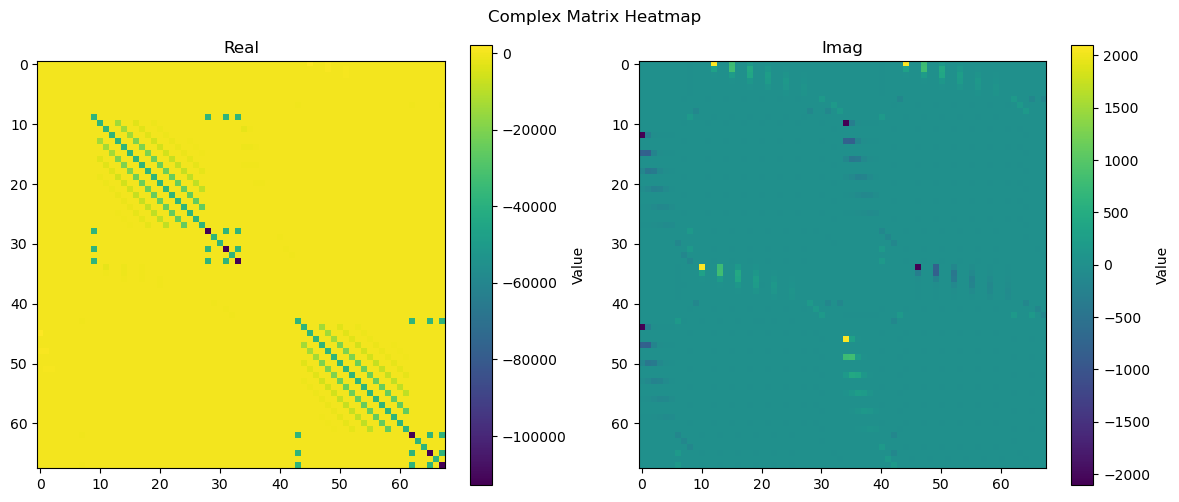

In [14]:
G_1 = g_matrix_4c(P_0)
F_1 = H_core + G_1

plot_map(F_1)

True
[-3.80617346e+04 -3.80617346e+04 -3.76494996e+04 -3.76494996e+04
 -3.75869603e+04 -3.75869603e+04 -3.75869603e+04 -3.75869603e+04
 -3.75804965e+04 -3.75804965e+04 -3.75659342e+04 -3.75659342e+04
 -3.75659342e+04 -3.75659342e+04 -3.75639531e+04 -3.75639531e+04
 -3.75636574e+04 -3.75636574e+04 -3.75616734e+04 -3.75616734e+04
 -3.75616734e+04 -3.75616734e+04 -3.75600502e+04 -3.75600502e+04
 -3.75600502e+04 -3.75600502e+04 -3.75593364e+04 -3.75593364e+04
 -3.75591557e+04 -3.75591557e+04 -3.75585158e+04 -3.75585158e+04
 -3.75585158e+04 -3.75585158e+04 -3.75582641e+04 -3.75582641e+04
 -3.75582641e+04 -3.75582641e+04 -3.75580125e+04 -3.75580125e+04
 -3.75579315e+04 -3.75579315e+04 -3.75578013e+04 -3.75578013e+04
 -3.75578013e+04 -3.75578013e+04 -3.75577328e+04 -3.75577328e+04
 -3.75577328e+04 -3.75577328e+04 -7.99721172e-01 -7.99721172e-01
  6.29913326e-01  6.29913326e-01  2.65704358e+00  2.65704358e+00
  2.65765065e+00  2.65765065e+00  2.65765065e+00  2.65765065e+00
  3.73013504e+00  3.

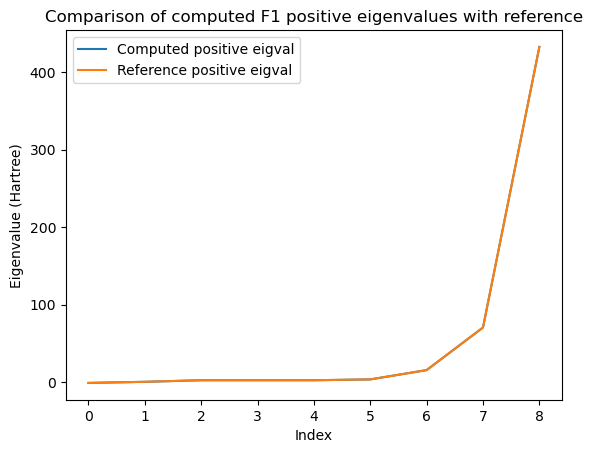

[np.float64(-0.799721172395712), np.float64(0.6299133257763648), np.float64(2.6570435781373116), np.float64(2.6576506541975995), np.float64(2.657650654210632), np.float64(3.730135041178289), np.float64(15.722799032726153), np.float64(70.61211210115704), np.float64(432.2854780418315)]
[-4.21259957e-05 -8.14273236e-05 -4.37160963e-04  6.05881976e-05
  6.05881106e-05  4.86380578e-04 -6.44972738e-05 -1.61025843e-04
 -2.74386968e-04]
Eigenvalues are the same for the first iteration: False
Mean absolute error for the first iteration: 0.18282970718101524
Max absolute error for the first iteration: 1.0426827874107403
Mean absolute error for the first iteration (pos eigvals): 0.00018535347265096695
False


In [15]:
F_p1 = X.T @ F_1 @ X
print(np.allclose(F_p1, F_p1.conj().T))

e1, w1 = np.linalg.eigh(F_p1)

idx = np.argsort(e1)
e1 = e1[idx]
w1 = w1[:, idx]

print(e1)

plot_pos_eigval(e1, reference=He_F1_eigvals, n=1)

e1_reduced = [ei for i, ei in enumerate(e1) if i % 2 == 0]

print(e1_reduced[-9:])
print((e1_reduced - He_F1_eigvals)[-9:])

plt.show()

print(f"Eigenvalues are the same for the first iteration: {np.allclose(e1_reduced, He_F1_eigvals)}")
print(f"Mean absolute error for the first iteration: {np.mean(np.abs(e1_reduced - He_F1_eigvals))}")
print(f"Max absolute error for the first iteration: {np.max(np.abs(e1_reduced - He_F1_eigvals))}")
print(f"Mean absolute error for the first iteration (pos eigvals): {np.mean(np.abs(e1_reduced[-9:] - He_F1_eigvals[-9:]))}")

print(np.allclose(e1_reduced, He_F1_eigvals))

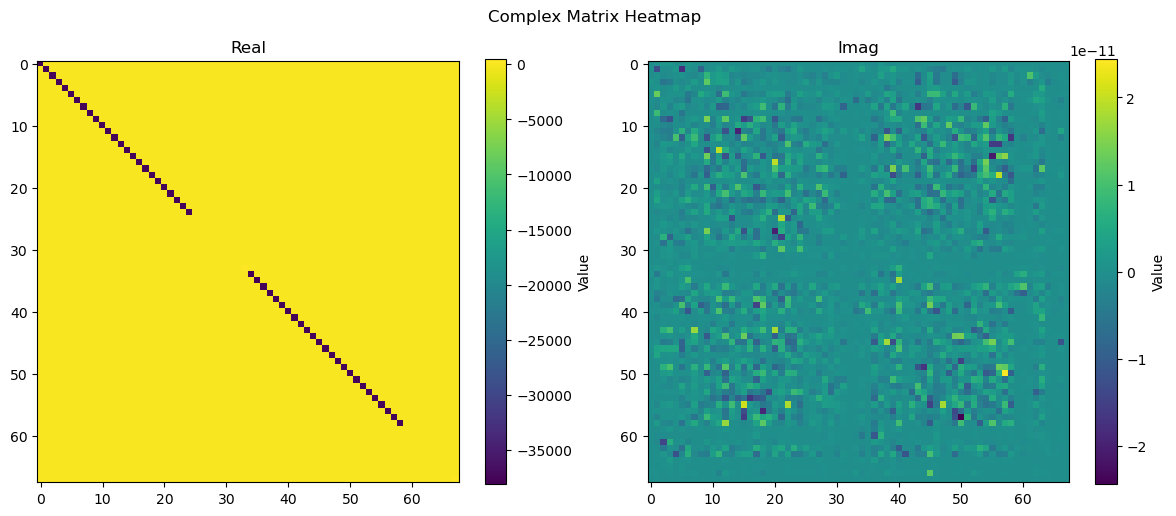

In [16]:
e1, w1 = rearange_eigval_eigvec(e1, w1)

F_diag1 = np.linalg.inv(w1) @ F_p1 @ w1

plot_map(F_diag1)

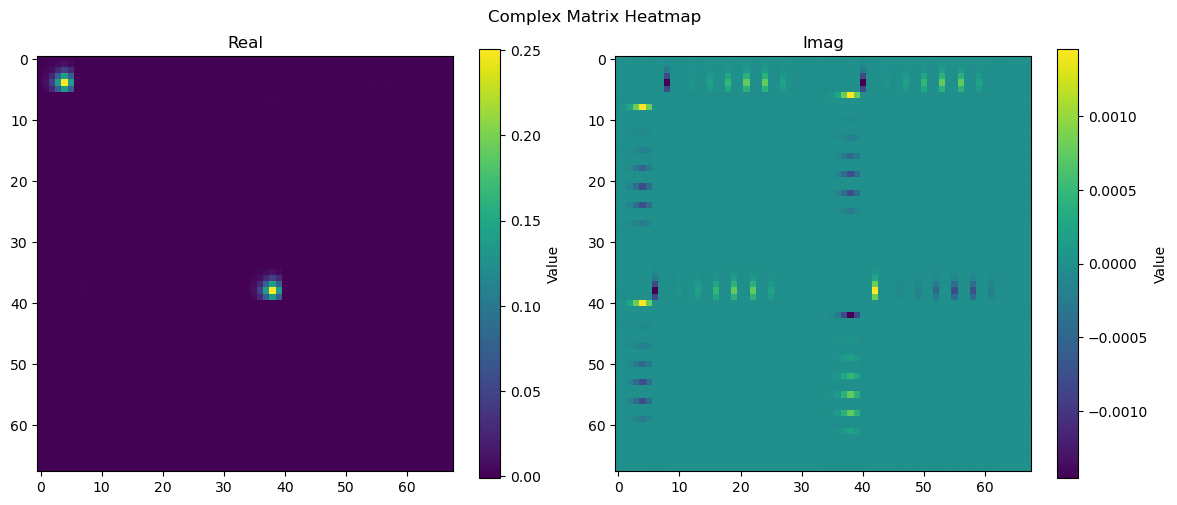

In [17]:
c_alpha_beta1 = X.T @ w1
P_1 = calc_p_matrix_comp(c_alpha_beta1.conj().T, c_alpha_beta1, total_occ_det)
plot_map(P_1)


# Second iteration

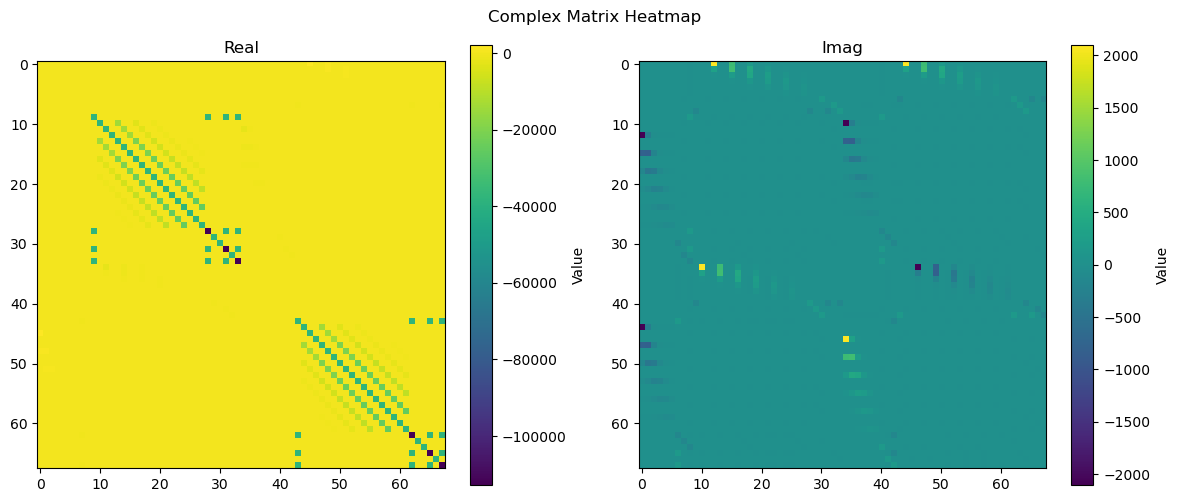

In [18]:
G_2 = g_matrix_4c(P_1)
F_2 = H_core + G_2

plot_map(F_2)

True
[-3.80622790e+04 -3.80622790e+04 -3.76499635e+04 -3.76499635e+04
 -3.75875056e+04 -3.75875056e+04 -3.75875056e+04 -3.75875056e+04
 -3.75808030e+04 -3.75808030e+04 -3.75664006e+04 -3.75664006e+04
 -3.75664006e+04 -3.75664006e+04 -3.75640944e+04 -3.75640944e+04
 -3.75637433e+04 -3.75637433e+04 -3.75617261e+04 -3.75617261e+04
 -3.75617261e+04 -3.75617261e+04 -3.75603585e+04 -3.75603585e+04
 -3.75603585e+04 -3.75603585e+04 -3.75593895e+04 -3.75593895e+04
 -3.75591880e+04 -3.75591880e+04 -3.75585771e+04 -3.75585771e+04
 -3.75585771e+04 -3.75585771e+04 -3.75584105e+04 -3.75584105e+04
 -3.75584105e+04 -3.75584105e+04 -3.75580206e+04 -3.75580206e+04
 -3.75580169e+04 -3.75580169e+04 -3.75578486e+04 -3.75578486e+04
 -3.75578486e+04 -3.75578486e+04 -3.75577382e+04 -3.75577382e+04
 -3.75577382e+04 -3.75577382e+04 -9.05929721e-01 -9.05929721e-01
  6.20562615e-01  6.20562615e-01  2.53407694e+00  2.53407694e+00
  2.53446875e+00  2.53446875e+00  2.53446875e+00  2.53446875e+00
  3.62554200e+00  3.

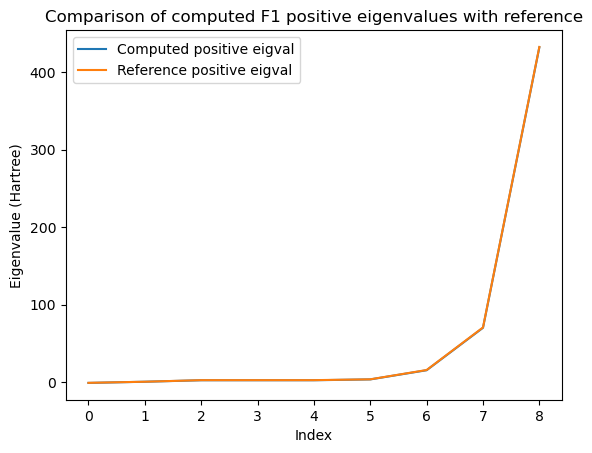

[np.float64(-0.9059297209518099), np.float64(0.6205626150397078), np.float64(2.5340769409776804), np.float64(2.5344687548082945), np.float64(2.5344687548430147), np.float64(3.6255420014867874), np.float64(15.44937017602456), np.float64(70.17561503647843), np.float64(431.7523436881542)]
[-1.26545352e-04 -1.80118660e-04 -3.16140722e-04 -5.92573917e-05
 -5.92574570e-05  3.72155687e-04 -1.75761875e-04 -2.61410422e-04
 -3.47089546e-04]
False
Eigenvalues are the same for the second iteration: False
Mean absolute error for the second iteration: 0.1672697137310533
Max absolute error for the second iteration: 0.917572212711093
Mean absolute error for the second iteration (pos eigvals): 0.00021085967919160572


In [19]:
F_p = X.T @ F_2 @ X
print(np.allclose(F_p, F_p.conj().T))

e2, w2 = np.linalg.eigh(F_p)

idx = np.argsort(e2)
e2 = e2[idx]
w2 = w2[:, idx]

print(e2)

plot_pos_eigval(e2, reference=He_F2_eigvals, n=1)

e2_reduced = [ei for i, ei in enumerate(e2) if i % 2 == 0]

print(e2_reduced[-9:])
print((e2_reduced - He_F2_eigvals)[-9:])

plt.show()

print(np.allclose(e2_reduced, He_F2_eigvals))

print(f"Eigenvalues are the same for the second iteration: {np.allclose(e2_reduced, He_F2_eigvals)}")
print(f"Mean absolute error for the second iteration: {np.mean(np.abs(e2_reduced - He_F2_eigvals))}")
print(f"Max absolute error for the second iteration: {np.max(np.abs(e2_reduced - He_F2_eigvals))}")
print(f"Mean absolute error for the second iteration (pos eigvals): {np.mean(np.abs(e2_reduced[-9:] - He_F2_eigvals[-9:]))}")